In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

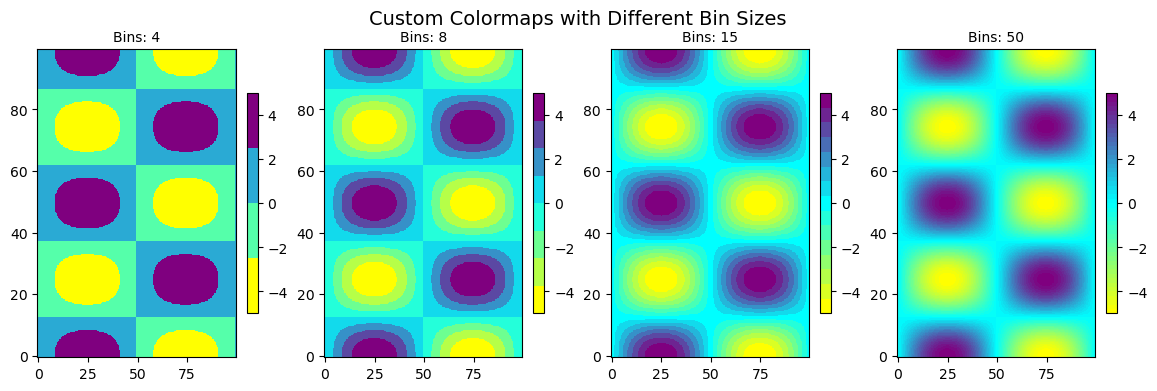

In [1]:
# 生成新的数据：使用不同的函数组合
x = np.linspace(0, 2 * np.pi, 100)  # 更加密集的x轴数据
y = np.linspace(0, 4 * np.pi, 100)  # 更加密集的y轴数据
X, Y = np.meshgrid(x, y)

# 生成Z数据，使用不同的组合函数
Z = np.sin(X) * np.cos(Y) * 5  # 正弦和余弦的组合函数

# 定义颜色的渐变方案，从黄色到青色再到紫色
colors = [(1, 1, 0), (0, 1, 1), (0.5, 0, 0.5)]  # Yellow -> Cyan -> Purple
cmap_name = 'new_custom_cmap'

# 设定不同的颜色映射“离散度”
n_bins_list = [4, 8, 15, 50]  # 离散的不同等级

# 创建图形和子图，布局为1行4列
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.3)

# 循环生成每个子图并使用不同的离散化颜色映射
for n_bins, ax in zip(n_bins_list, axs):
    # 基于自定义颜色列表创建颜色映射
    cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
    
    # 绘制图像，并设置颜色映射
    img = ax.imshow(Z, cmap=cmap, origin='lower', aspect='auto')
    
    # 为每个子图添加颜色条
    fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.05)
    
    # 设置标题，显示当前的颜色映射级数
    ax.set_title(f"Bins: {n_bins}", fontsize=10)

# 设置整体标题和显示图形
fig.suptitle('Custom Colormaps with Different Bin Sizes', fontsize=14)
plt.show()


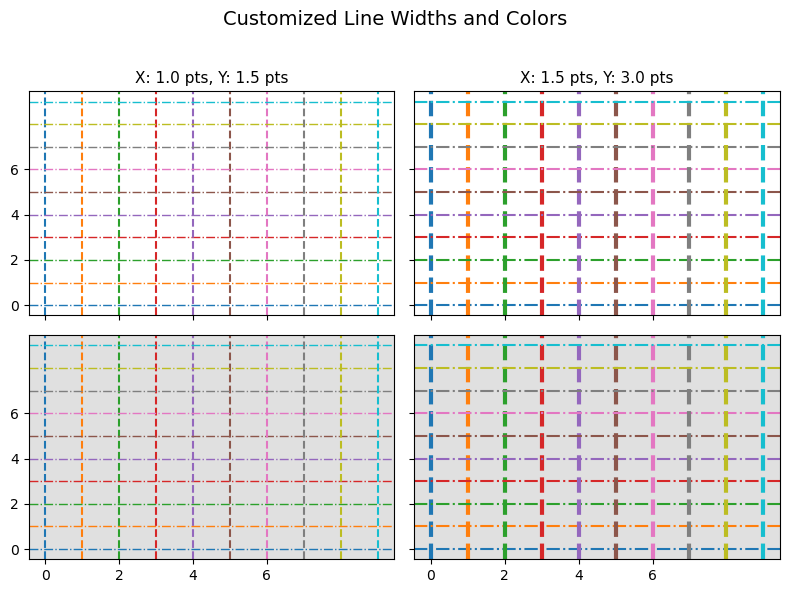

In [5]:
# 获取默认颜色循环列表，并设置线条宽度基础
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
base_lw = plt.rcParams['lines.linewidth']  # 基础线宽
thin_lw = base_lw / 1.5  # 较细的线条宽度
thick_lw = base_lw * 2  # 较粗的线条宽度

# 创建图形和子图，设置2行2列的布局，并共享x轴和y轴
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), sharex=True, sharey=True)

# 设置不同列的线宽变化
for col_idx in range(2):
    if col_idx == 0:
        # 第一列使用较细的x方向线条和默认的y方向线条
        line_wx, line_wy = thin_lw, base_lw
    else:
        # 第二列使用默认的x方向线条和较粗的y方向线条
        line_wx, line_wy = base_lw, thick_lw

    # 在每个子图中绘制横线和竖线
    for row_idx in range(2):
        for i, color in enumerate(color_list):
            # 横向画线，使用指定的线宽和颜色
            axes[row_idx, col_idx].axhline(y=i, color=color, lw=line_wx, linestyle='-.')

            # 纵向画线，使用指定的线宽和颜色
            axes[row_idx, col_idx].axvline(x=i, color=color, lw=line_wy, linestyle='--')

        # 修改背景颜色，仅对第二行设置
        axes[1, col_idx].set_facecolor('#e0e0e0')  # 设置为浅灰色背景
        axes[1, col_idx].xaxis.set_ticks(np.arange(0, 8, 2))  # 设置x轴刻度

    # 设置子图标题，显示线宽信息
    axes[0, col_idx].set_title(f'X: {line_wx:.1f} pts, Y: {line_wy:.1f} pts', fontsize=11)

# 设置y轴刻度范围，间隔为2
for row_idx in range(2):
    axes[row_idx, 0].yaxis.set_ticks(np.arange(0, 8, 2))

# 设置整体图形的标题
fig.suptitle('Customized Line Widths and Colors', fontsize=14)

# 显示图形
plt.tight_layout(rect=[0, 0, 1, 0.96])  # 调整布局并留出标题空间
plt.show()

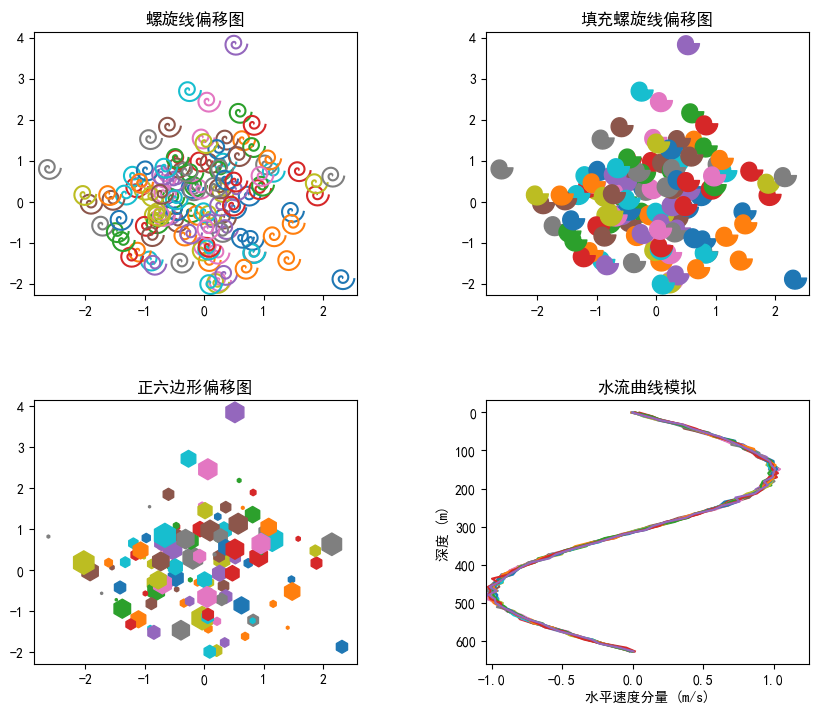

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import collections, transforms

# 设置基础参数
num_points = 60   # 点的数量
num_patterns = 120 # 偏移数量

# 生成螺旋形数据
radius = np.linspace(0, 10, num_points)
angles = np.linspace(0, 4*np.pi, num_points)
x_vals = radius * np.cos(angles) 
y_vals = radius * np.sin(angles) 
spiral_data = np.column_stack([x_vals, y_vals])

# 随机生成偏移值
random_state = np.random.RandomState(42) # 使用不同的随机数种子
offsets = random_state.randn(num_patterns, 2)

# 颜色使用默认的颜色循环
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 创建子图布局
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.subplots_adjust(top=0.9, hspace=0.4, wspace=0.4)

# 绘制螺旋线图，应用偏移
spiral_collection = collections.LineCollection(
    [spiral_data], offsets=offsets, offset_transform=axes[0, 0].transData
)
# 对偏移应用变换，使得坐标点与像素一致
transform = fig.dpi_scale_trans + transforms.Affine2D().scale(1.0 / 80.0)
spiral_collection.set_transform(transform)
spiral_collection.set_color(color_cycle)

axes[0, 0].add_collection(spiral_collection, autolim=True)
axes[0, 0].autoscale_view()
axes[0, 0].set_title('螺旋线偏移图')

# 绘制填充的螺旋线图
filled_collection = collections.PolyCollection(
    [spiral_data], offsets=offsets, offset_transform=axes[0, 1].transData
)
filled_collection.set_transform(transform)
filled_collection.set_color(color_cycle)
axes[0, 1].add_collection(filled_collection, autolim=True)
axes[0, 1].autoscale_view()
axes[0, 1].set_title('填充螺旋线偏移图')

# 正多边形图形
polygon_collection = collections.RegularPolyCollection(
    6, sizes=np.abs(x_vals) * 15, offsets=offsets, offset_transform=axes[1, 0].transData
)
polygon_collection.set_transform(transform)
polygon_collection.set_color(color_cycle)
axes[1, 0].add_collection(polygon_collection, autolim=True)
axes[1, 0].autoscale_view()
axes[1, 0].set_title('正六边形偏移图')

# 模拟水流曲线
num_curves = 15
curve_segments = []
depths = np.linspace(0, 2*np.pi, num_points)
for i in range(num_curves):
    noise = 0.02 * random_state.randn(num_points)
    current_curve = np.column_stack([(np.sin(depths) + noise), depths * 100])
    curve_segments.append(current_curve)

line_collection = collections.LineCollection(curve_segments, offsets=(0.1, 0))
line_collection.set_color(color_cycle)
axes[1, 1].add_collection(line_collection, autolim=True)
axes[1, 1].autoscale_view()
axes[1, 1].set_ylim(axes[1, 1].get_ylim()[::-1])  # 翻转y轴
axes[1, 1].set_title('水流曲线模拟')
axes[1, 1].set_xlabel('水平速度分量 (m/s)')
axes[1, 1].set_ylabel('深度 (m)')

plt.show()

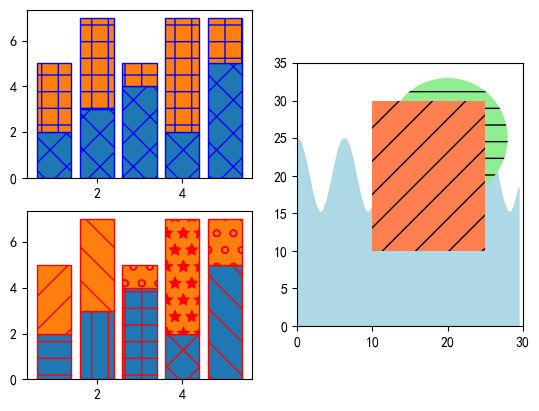

In [17]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Rectangle, Circle

# 生成数据
x_positions = np.arange(1, 6)
data1 = np.array([2, 3, 4, 2, 5])
data2 = np.array([3, 4, 1, 5, 2])

# 创建图形和子图
fig = plt.figure()
axs = fig.subplot_mosaic([['hist1', 'shapes'], ['hist2', 'shapes']])

# 绘制条形图1
axs['hist1'].bar(x_positions, data1, edgecolor='blue', hatch='x')
axs['hist1'].bar(x_positions, data2, bottom=data1, edgecolor='blue', hatch='+')

# 绘制条形图2
# 为每个条形图的条数指定不同的hatch样式
hatch_styles1 = ['-', '|', '+', 'x', '\\']
hatch_styles2 = ['/', '\\', 'o', '*', 'o']

axs['hist2'].bar(x_positions, data1, edgecolor='red', hatch=hatch_styles1)
axs['hist2'].bar(x_positions, data2, bottom=data1, edgecolor='red', hatch=hatch_styles2)

# 创建x数据用于填充区域
x_fill = np.arange(0, 30, 0.5)
y_fill = np.cos(x_fill) * 5 + 20

# 在'shapes'子图中填充区域
axs['shapes'].fill_between(x_fill, y_fill, y2=0, hatch='\\', color='lightblue', zorder=1)
axs['shapes'].add_patch(Circle((20, 25), 8, fill=True, hatch='-', facecolor='lightgreen'))
axs['shapes'].add_patch(Rectangle((10, 10), 15, 20, fill=True, hatch='/', facecolor='coral'))

# 设置坐标轴的范围和比例
axs['shapes'].set_xlim([0, 30])
axs['shapes'].set_ylim([0, 35])
axs['shapes'].set_aspect(1)

# 显示图形
plt.show()

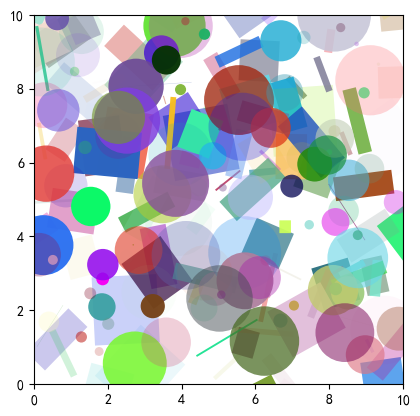

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

# 设置随机数种子以确保可重复性
np.random.seed(42)

# 设置图形的数量
num_shapes = 200

# 生成随机的矩形和圆形数据
rectangles = [
    Rectangle(xy=np.random.rand(2) * 10, width=np.random.rand() * 2, height=np.random.rand() * 2, angle=np.random.rand() * 360)
    for _ in range(num_shapes // 2)
]

circles = [
    Circle(xy=np.random.rand(2) * 10, radius=np.random.rand())
    for _ in range(num_shapes // 2)
]

# 创建图形和子图
fig, ax = plt.subplots()

# 设置坐标轴范围并保持比例一致
ax.set(xlim=(0, 10), ylim=(0, 10), aspect="equal")

# 添加矩形到图中
for rect in rectangles:
    ax.add_artist(rect)
    rect.set_clip_box(ax.bbox)  # 设置剪辑框
    rect.set_alpha(np.random.rand())  # 设置透明度
    rect.set_facecolor(np.random.rand(3))  # 随机生成颜色

# 添加圆形到图中
for circ in circles:
    ax.add_artist(circ)
    circ.set_clip_box(ax.bbox)  # 设置剪辑框
    circ.set_alpha(np.random.rand())  # 设置透明度
    circ.set_facecolor(np.random.rand(3))  # 随机生成颜色

# 显示图形
plt.show()

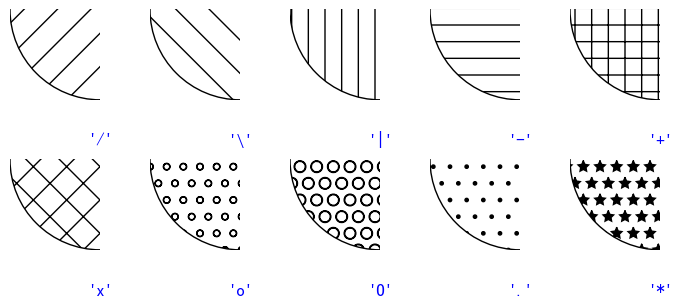

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 创建2x5布局的子图，并设置图形大小
fig, axs = plt.subplots(2, 5, constrained_layout=True, figsize=(7, 3))

# 定义不同的填充图案，使用圆圈替代矩形
hatch_patterns = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

# 自定义函数，绘制带有填充图案的圆形
def draw_circle_with_hatch(ax, hatch_pattern):
    # 在子图上添加一个圆圈，设置填充图案
    circle = Circle((1, 1), radius=1, fill=False, hatch=hatch_pattern, edgecolor='black')
    ax.add_patch(circle)
    
    # 添加填充图案的标签文字
    ax.text(1, -0.5, f"'{hatch_pattern}'", size=12, ha="center", color='blue')
    
    # 关闭坐标轴显示，保持比例
    ax.set_aspect('equal')
    ax.axis('off')

# 遍历子图和填充图案，绘制每个子图中的图形
for ax, hatch in zip(axs.flat, hatch_patterns):
    draw_circle_with_hatch(ax, hatch)

# 显示最终的图形
plt.show()

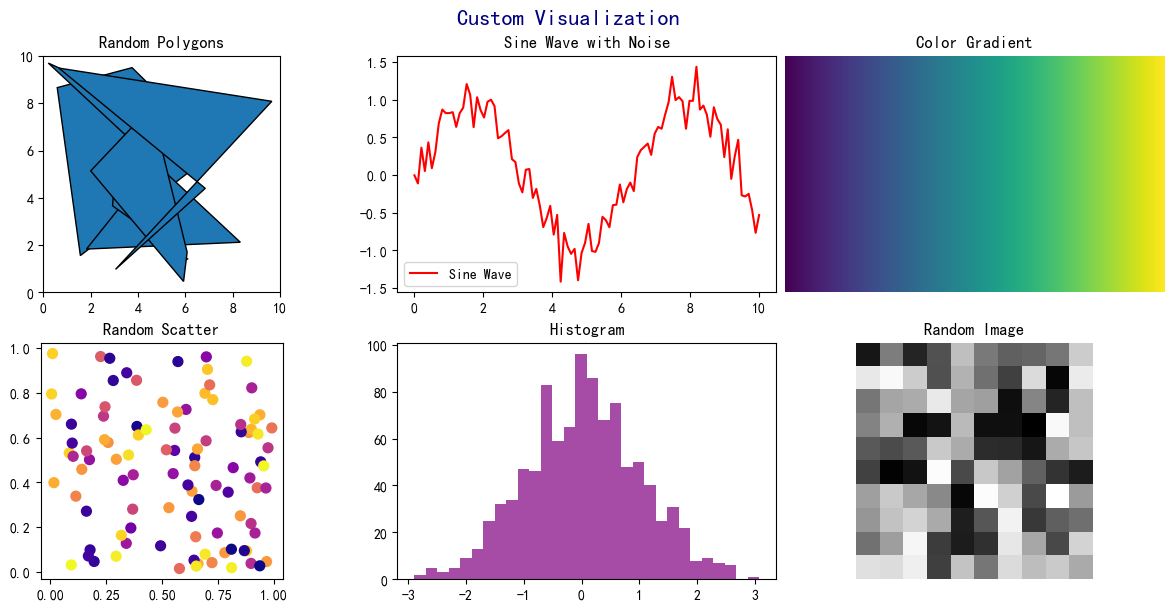

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon

# 设置随机数种子，保证结果可重复
np.random.seed(42)

def plot_random_polygons(ax, num_polygons=5):
    """绘制随机多边形"""
    for _ in range(num_polygons):
        # 随机生成多边形的顶点
        vertices = np.random.rand(4, 2) * 10
        polygon = Polygon(vertices, closed=True, fill=True, edgecolor='k')
        ax.add_patch(polygon)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_title("Random Polygons")
    ax.set_aspect('equal', adjustable='box')

def plot_sine_wave(ax):
    """绘制带有随机噪声的正弦波"""
    x = np.linspace(0, 10, 100)
    y = np.sin(x) + np.random.normal(0, 0.2, len(x))
    ax.plot(x, y, color='r', label='Sine Wave')
    ax.set_title("Sine Wave with Noise")
    ax.legend()

def plot_color_gradient(ax):
    """绘制颜色渐变的条形图"""
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap='viridis')
    ax.set_title("Color Gradient")
    ax.axis('off')

def plot_random_scatter(ax):
    """绘制随机散点图"""
    x = np.random.rand(100)
    y = np.random.rand(100)
    colors = np.random.rand(100)
    ax.scatter(x, y, c=colors, cmap='plasma', s=50)
    ax.set_title("Random Scatter")
    ax.set_aspect('equal')

def plot_histogram(ax):
    """绘制随机数据的直方图"""
    data = np.random.randn(1000)
    ax.hist(data, bins=30, color='purple', alpha=0.7)
    ax.set_title("Histogram")

def plot_image(ax):
    """绘制随机生成的图像"""
    img = np.random.rand(10, 10)
    ax.imshow(img, cmap='gray', interpolation='nearest')
    ax.set_title("Random Image")
    ax.axis('off')

def plot_custom_figure():
    """设置并绘制不同类型的子图"""
    fig, axs = plt.subplots(2, 3, figsize=(12, 6), layout='constrained')

    # 调用各个绘图函数
    plot_random_polygons(axs[0, 0])
    plot_sine_wave(axs[0, 1])
    plot_color_gradient(axs[0, 2])
    plot_random_scatter(axs[1, 0])
    plot_histogram(axs[1, 1])
    plot_image(axs[1, 2])

    # 设置图表标题
    fig.suptitle("Custom Visualization", fontsize=16, color='navy')

if __name__ == "__main__":
    plot_custom_figure()
    plt.show()

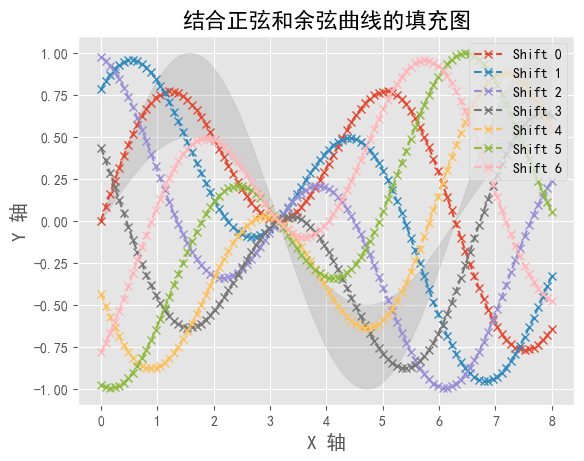

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 使用 'ggplot' 风格背景样式
plt.style.use('ggplot')

# 创建图形和子图
fig, ax = plt.subplots()

# 定义x轴的范围和步长
L = 8  # 延长x的范围
x = np.linspace(0, L, 100)

# 获取颜色循环的数量，并引入一个新的相位偏移
ncolors = len(plt.rcParams['axes.prop_cycle'])
shifts = np.linspace(0, 2*np.pi, ncolors, endpoint=False)

# 使用不同的数学函数来生成y值
for i, shift in enumerate(shifts):
    y = np.sin(x + shift) * np.cos(x / 2)  # 使用正弦和余弦的组合
    ax.plot(x, y, marker='x', linestyle='--', label=f'Shift {i}')

# 添加填充区域，以增强视觉效果
ax.fill_between(x, np.sin(x), np.sin(x) * 0.5, color='gray', alpha=0.2)

# 设置坐标轴标签和标题
ax.set_xlabel('X 轴', fontsize=14)
ax.set_ylabel('Y 轴', fontsize=14)
ax.set_title("结合正弦和余弦曲线的填充图", fontsize=16)

# 添加图例以区分不同的曲线
ax.legend(loc='upper right', fontsize=10)

# 展示图形
plt.show()